In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [41]:
from sklearn.metrics import classification_report
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,IsolationForest
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBpipeline
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,recall_score,accuracy_score

In [42]:
np.random.seed(42)
n_samples=10000
n_fraud=100

normal = pd.DataFrame({
    'amount'    : np.random.exponential(50, n_samples),
    'hour'      : np.random.randint(0, 24, n_samples),
    'v1'        : np.random.normal(0, 1, n_samples),
    'v2'        : np.random.normal(0, 1, n_samples),
    'v3'        : np.random.normal(0, 1, n_samples),
    'v4'        : np.random.normal(0, 1, n_samples),
    'v5'        : np.random.normal(0, 1, n_samples),
    'Class'     : 0
})

# Fraud transactions (different pattern!)
fraud = pd.DataFrame({
    'amount'    : np.random.exponential(200, n_fraud),
    'hour'      : np.random.randint(0, 6, n_fraud),
    'v1'        : np.random.normal(3, 1, n_fraud),
    'v2'        : np.random.normal(-3, 1, n_fraud),
    'v3'        : np.random.normal(2, 1, n_fraud),
    'v4'        : np.random.normal(-2, 1, n_fraud),
    'v5'        : np.random.normal(3, 1, n_fraud),
    'Class'     : 1
})

In [43]:
df=pd.concat([normal,fraud],ignore_index=True)
df=df.sample(frac=1,random_state=42).reset_index(drop=True)
print(df.shape)
print(df.isnull().sum())
print(df['Class'].value_counts())
print(df['Class'].mean()*100)

(10100, 8)
amount    0
hour      0
v1        0
v2        0
v3        0
v4        0
v5        0
Class     0
dtype: int64
Class
0    10000
1      100
Name: count, dtype: int64
0.9900990099009901


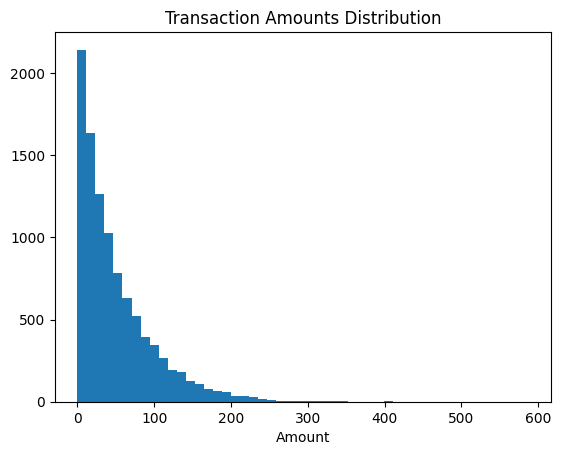

Average: 50.31
Min: 0.01
Max: 587.07


In [44]:
# Run this to see the distribution!
amounts = np.random.exponential(50, 10000)
plt.hist(amounts, bins=50)
plt.title('Transaction Amounts Distribution')
plt.xlabel('Amount')
plt.show()

print("Average:", amounts.mean().round(2))
print("Min:", amounts.min().round(2))
print("Max:", amounts.max().round(2))

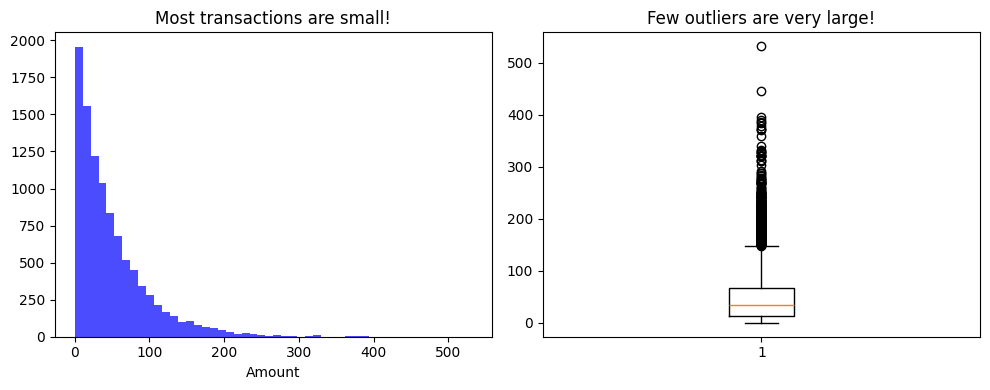

Mean:   $49.21
Median: $34.60
Min:    $0.00
Max:    $531.82


In [45]:
amounts = np.random.exponential(50, 10000)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(amounts, bins=50, color='blue', alpha=0.7)
plt.title('Most transactions are small!')
plt.xlabel('Amount')

plt.subplot(1, 2, 2)
plt.boxplot(amounts)
plt.title('Few outliers are very large!')

plt.tight_layout()
plt.show()

print(f"Mean:   ${amounts.mean():.2f}")
print(f"Median: ${np.median(amounts):.2f}")
print(f"Min:    ${amounts.min():.2f}")
print(f"Max:    ${amounts.max():.2f}")

In [46]:
df['is_night']=(df['amount']<=6).astype(int)
amount_threshold=df['amount'].quantile(0.95)
df['high_amount']=(df['amount']>amount_threshold).astype(int)
df['amount_log']=np.log1p(df['amount'])
print("new features")
print(df[['amount','hour','is_night','high_amount','amount_log']].head(10))
print(df.groupby('Class')['is_night'].mean().round(2))
print(df.groupby('Class')['high_amount'].mean().round(2))

new features
       amount  hour  is_night  high_amount  amount_log
0   58.658492    11         0            0    4.088636
1   79.577621     4         0            0    4.389221
2  170.754596     8         0            1    5.146067
3    4.593316     7         1            0    1.721572
4   64.748028    20         0            0    4.185830
5   88.149651     8         0            0    4.490316
6  100.233686    15         0            0    4.617432
7   51.399979    17         0            0    3.958906
8   21.531105    23         0            0    3.114897
9   20.337751     5         0            0    3.060478
Class
0    0.12
1    0.02
Name: is_night, dtype: float64
Class
0    0.05
1    0.52
Name: high_amount, dtype: float64


In [47]:
x=df.drop('Class',axis=1)
y=df['Class']
print("x shape: ",x.shape)
print("y shape: ",y.shape)
print(y.value_counts())
print(x.columns.tolist())

x shape:  (10100, 10)
y shape:  (10100,)
Class
0    10000
1      100
Name: count, dtype: int64
['amount', 'hour', 'v1', 'v2', 'v3', 'v4', 'v5', 'is_night', 'high_amount', 'amount_log']


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.mean().round(2))
print(y_test.mean().round(2))
print(y_train.sum())
print(y_test.sum())

(8080, 10)
(2020, 10)
0.01
0.01
81
19


In [49]:
from sklearn.compose import ColumnTransformer
numeric_cols=['amount','hour','v1','v2','v3','v4','v5','amount_log']
binary_cols=['is_night','high_amount']
preprocessor=ColumnTransformer([('num',StandardScaler(),numeric_cols),
                                ('bin','passthrough',binary_cols)])
print("numerics cols: ",len(numeric_cols))
print("binary cols: ",len(binary_cols))


numerics cols:  8
binary cols:  2


In [50]:
models={
    'logistic regression':LogisticRegression(max_iter=1000,random_state=42),
    'random forest':RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1),
    'xg boost':XGBClassifier(random_state=42,eval_metric='logloss',n_estimator=50,verbosity=0)
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
print("number of models: ",len(models))

number of models:  3


In [51]:
result={}
for name,model in models.items():
  full_pipeline=IMBpipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('model',model)])
  recall_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='recall')
  f1_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='f1')
  roc_auc_score=cross_val_score(full_pipeline,x_train,y_train,cv=cv,scoring='roc_auc')
  result[name]={
      'recall':round(recall_score.mean(),4),
      'f1':round(f1_score.mean(),4),
      'roc auc':round(roc_auc_score.mean(),4)
  }
  print(f"{name} done")
for name,score in result.items():
  print(f"{name}")
  print(f"{name} : {score}")


logistic regression done
random forest done
xg boost done
logistic regression
logistic regression : {'recall': np.float64(0.9875), 'f1': np.float64(0.9586), 'roc auc': np.float64(1.0)}
random forest
random forest : {'recall': np.float64(0.9147), 'f1': np.float64(0.9484), 'roc auc': np.float64(0.9999)}
xg boost
xg boost : {'recall': np.float64(0.9632), 'f1': np.float64(0.9579), 'roc auc': np.float64(0.9998)}


accuracy:  0.999009900990099
f1 score:  0.95
recall:  1.0
roc_auc:  1.0
classification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.90      1.00      0.95        19

    accuracy                           1.00      2020
   macro avg       0.95      1.00      0.97      2020
weighted avg       1.00      1.00      1.00      2020



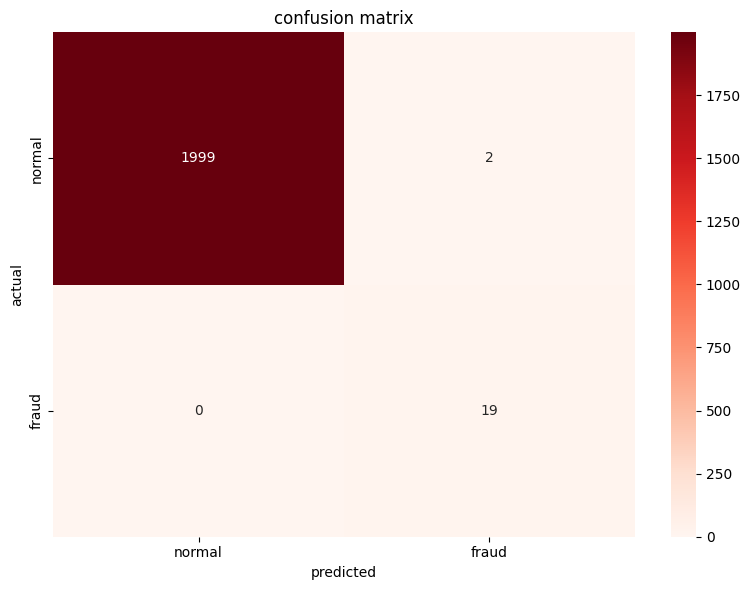

In [57]:
from sklearn.metrics import f1_score as f1_metric,recall_score as recall_metric,roc_auc_score as roc_auc_metric
base_pipeline=IMBpipeline([('preprocessor',preprocessor),('smote',SMOTE(random_state=42)),('model',LogisticRegression(max_iter=1000,random_state=42))])
base_pipeline.fit(x_train,y_train)
y_pred=base_pipeline.predict(x_test)
y_pred_proba=base_pipeline.predict_proba(x_test)[:,1]
print("accuracy: ",accuracy_score(y_test,y_pred))
print("f1 score: ",f1_metric(y_test,y_pred))
print("recall: ",recall_metric(y_test,y_pred))
print("roc_auc: ",roc_auc_metric(y_test,y_pred_proba))
print("classification report: ",classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['normal','fraud'],yticklabels=['normal','fraud'],cmap='Reds')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.tight_layout()
plt.show()
